In [ ]:
import scipy.io
import numpy as np

import pickle
from collections import Counter
from typing import Dict, List, Optional, Tuple

import igraph as ig
import scipy.sparse

## Checking .mat keys

In [14]:
import scipy.io
import numpy as np

mat_path = r"C:\Users\Ana\OneDrive\Escritorio\ARTORG\XiangJi\ML20180815_240_c5o1_578.mat"

mat = scipy.io.loadmat(
    mat_path,
    struct_as_record=False,
    squeeze_me=True
)

print("MAT keys:")
print(mat.keys())

info = mat["info"]

print("\nINFO TYPE:")
print(type(info))

print("\nINFO DIR:")
print([x for x in dir(info) if not x.startswith("_")])

MAT keys:
dict_keys(['__header__', '__version__', '__globals__', 'num', 'link', 'endpoint', 'isopoint', 'node', 'radius', 'label', 'info'])

INFO TYPE:
<class 'scipy.io.matlab._mio5_params.mat_struct'>

INFO DIR:
['bbox_mmll', 'bbox_mmxx', 'combined_grid_mmxx_grid', 'combined_grid_xyz_label', 'dataset_name', 'dataset_size', 'grid_version', 'grid_xy_idx', 'idx_1', 'idx_2', 'layer', 'mask_annotated', 'stack', 'sub_grid_global_bbox_mmll', 'sub_grid_global_bbox_mmxx', 'sub_grid_ind', 'sub_grid_sub', 'sub_grid_valid_ind', 'sub_grid_version']


## Checking Radii >= 1.8 um
According to Ji's email, if the majority of radii are >= 1.8 um, it means radii has already been corrected and needs no rescaling/shrinkage correction

dict_keys(['__header__', '__version__', '__globals__', 'num', 'link', 'endpoint', 'isopoint', 'node', 'radius', 'label', 'info'])
n radii: 811341
median radius: 2.0
mean radius: 2.2777942883499667
% radii >= 1.8 µm: 83.16
% radii < 1.8 µm: 16.84


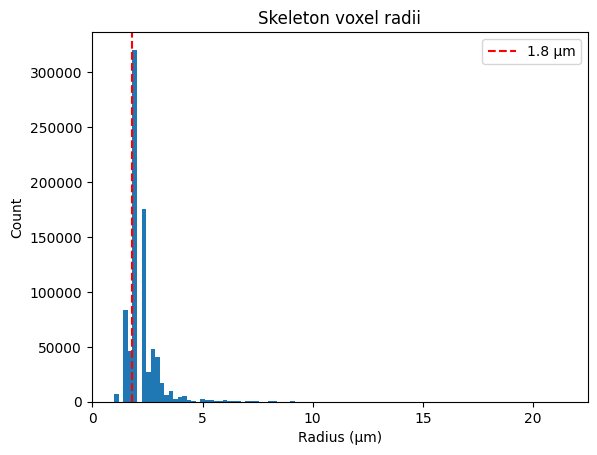

In [15]:
from scipy import sparse
import numpy as np


mat = scipy.io.loadmat(
    r"C:\Users\Ana\OneDrive\Escritorio\ARTORG\XiangJi\ML20180815_240_c5o1_578.mat",
    struct_as_record=False,
    squeeze_me=True # This option simplifies the structure of the loaded data, making it easier to access the fields without needing to use additional indexing -> mat["link"][0,0]["cc_ind"]
)

print(mat.keys())



rad = mat["radius"]

if sparse.issparse(rad):
    radii = rad.data.astype(float)   # valores no nulos
else:
    radii = np.asarray(rad, dtype=float).ravel()
    radii = radii[np.isfinite(radii)]
    radii = radii[radii > 0]         # opcional: quitar fondo/ceros

print("n radii:", len(radii))
print("median radius:", np.median(radii))
print("mean radius:", np.mean(radii))

greater = radii >= 1.8
lower = radii < 1.8

pct_ge = 100 * greater.mean()
pct_lt = 100 * lower.mean()

print(f"% radii >= 1.8 µm: {pct_ge:.2f}")
print(f"% radii < 1.8 µm: {pct_lt:.2f}")

import matplotlib.pyplot as plt

plt.hist(radii, bins=100)
plt.axvline(1.8, linestyle="--", color="red", label="1.8 µm")
plt.xlabel("Radius (µm)")
plt.ylabel("Count")
plt.title("Skeleton voxel radii")
plt.legend()
plt.show()

## Check compliance .pkl - .mat

In [ ]:
mvn = pickle.load(open(
    r"C:\Users\Ana\OneDrive\Escritorio\ARTORG\XiangJi\ML20180815_240_c5o1_578_mvn1.pkl",
    "rb"
)
)

print(mvn.es.attributes())
print(mvn.vs.attributes())

print(mvn.vcount())
print(mvn.ecount())

['points', 'lengths2', 'length', 'diameters', 'diameter', 'nkind', 'connectivity']
['coords', 'diameter', 'index']
11732
16640


In [17]:
import scipy.io
import numpy as np

mat = scipy.io.loadmat(
    r"C:\Users\Ana\OneDrive\Escritorio\ARTORG\XiangJi\ML20180815_240_c5o1_578.mat",
    struct_as_record=False,
    squeeze_me=True,
)

node_cc = np.asarray(mat["node"].cc_ind).squeeze()
link_cc = np.asarray(mat["link"].cc_ind).squeeze()
connected = np.asarray(mat["link"].connected_node_label).astype(int)
open_links = np.sum((connected[:, 0] == 0) | (connected[:, 1] == 0))
closed_links = np.sum((connected[:, 0] > 0) & (connected[:, 1] > 0))

print("node CC count:", len(np.asarray(mat["node"].cc_ind).squeeze()))
print("link CC count:", len(np.asarray(mat["link"].cc_ind).squeeze()))
print("connected rows:", connected.shape[0])
print("open links:", open_links)
print("closed links:", closed_links)

node CC count: 11732
link CC count: 18973
connected rows: 18973
open links: 2333
closed links: 16640


## Compare MVN1 - Ji MVN

In [19]:
# Compare MVN1 vs Ji graph: edge lengths by nkind
# nkind: 2=artery, 3=vein, 4=capillary
import pickle
import pandas as pd
import numpy as np

def load_graph(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def edge_length_summary_by_nkind(G, graph_name="graph", nkind_filter=None):
    """Summarize edge lengths by vessel type (nkind).
    
    Parameters
    ----------
    G : igraph.Graph
        The graph to analyze.
    graph_name : str
        Name of the graph for identification.
    nkind_filter : list, optional
        If provided, only include these nkind values.
    """
    df = pd.DataFrame({
        "nkind": G.es["nkind"],
        "length": G.es["length"],
    })
    
    # Remove rows with missing nkind or length
    df = df.dropna(subset=["nkind", "length"]).copy()
    df["nkind"] = df["nkind"].astype(int)
    
    # Filter by nkind if specified
    if nkind_filter is not None:
        df = df[df["nkind"].isin(nkind_filter)]
    
    # Aggregate by nkind
    summary = (
        df.groupby("nkind")["length"]
        .agg(["count", "sum", "mean", "median", "std"])
        .reset_index()
        .round(4)
    )
    summary["graph"] = graph_name
    return summary

# Load both graphs
path1 = r"C:\Users\Ana\OneDrive\Escritorio\ARTORG\MVN1 files\MVN1_corrected_SI.pkl"
path2 = r"C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578_mvn1_scaled_offset.pkl"

g1 = load_graph(path1)
g2 = load_graph(path2)

# First, check all nkinds in MVN1
print("=== All nkinds in MVN1 ===")
mvn1_nkinds = pd.Series(g1.es["nkind"]).dropna().unique()
print(sorted(mvn1_nkinds))

print("\n=== All nkinds in Ji graph ===")
ji_nkinds = pd.Series(g2.es["nkind"]).dropna().unique()
print(sorted(ji_nkinds))

# NOTA: MVN1 puede tener nkinds 0, 1, 5 de edges sin anotar o mal anotados
# Filtrar solo los 3 tipos esperados: 2=artery, 3=vein, 4=capillary
expected_nkinds = [2, 3, 4]

# Compute summaries filtrando solo los nkinds esperados
s1 = edge_length_summary_by_nkind(g1, "MVN1", nkind_filter=expected_nkinds)
s2 = edge_length_summary_by_nkind(g2, "Ji graph", nkind_filter=expected_nkinds)

# Combine and display
compare = pd.concat([s1, s2], ignore_index=True)
print("\n=== Total edge lengths by vessel type (nkind 2, 3, 4 only) ===\n")
print(compare.sort_values(["nkind", "graph"]).to_string(index=False))

# Show side-by-side comparison of totals
print("\n=== Total length (sum) by nkind ===\n")
totals = compare.pivot_table(index="nkind", columns="graph", values="sum")
nkind_names = {2: "Artery (2)", 3: "Vein (3)", 4: "Capillary (4)"}
totals.index = totals.index.map(nkind_names)
print(totals)

print("\n=== Edge count by nkind ===\n")
counts = compare.pivot_table(index="nkind", columns="graph", values="count")
counts.index = counts.index.map(nkind_names)
print(counts)

C:\Users\Ana\AppData\Local\Temp\ipykernel_2676\3378224354.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)


=== All nkinds in MVN1 ===
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

=== All nkinds in Ji graph ===
[np.int64(2), np.int64(3), np.int64(4)]

=== Total edge lengths by vessel type (nkind 2, 3, 4 only) ===

 nkind  count         sum    mean  median     std    graph
     2    151  11869.7573 78.6077 53.2352 83.5773 Ji graph
     2    129      0.0105  0.0001  0.0001  0.0001     MVN1
     3    646  22445.5925 34.7455 27.2595 32.3056 Ji graph
     3    232      0.0109  0.0000  0.0000  0.0000     MVN1
     4  15843 981412.2077 61.9461 46.7302 49.2419 Ji graph
     4  11635      0.7960  0.0001  0.0001  0.0001     MVN1

=== Total length (sum) by nkind ===

graph             Ji graph    MVN1
nkind                             
Artery (2)      11869.7573  0.0105
Vein (3)        22445.5925  0.0109
Capillary (4)  981412.2077  0.7960

=== Edge count by nkind ===

graph          Ji graph     MVN1
nkind                           
Artery (2)        151.0    129.0
Ve

=== Unit analysis ===
MVN1: stored in SI units (meters) → convert to μm by multiplying by 1e6
Ji graph: stored in voxels (1 voxel = 1 μm isotropic) → already in μm
→ Both graphs will be compared in μm

=== MVN1 nkind distribution (all values, in μm) ===

   nkind  count        sum    mean
0      0     20    3526.47  176.32
1      1     54    4191.65   77.62
2      2    129   10507.36   81.45
3      3    232   10902.45   46.99
4      4  11635  796025.92   68.42
5      5      1       7.97    7.97

=== Ji graph nkind distribution (in μm) ===

   nkind  count        sum   mean
0      2    151   11869.76  78.61
1      3    646   22445.59  34.75
2      4  15843  981412.21  61.95

=== Total lengths by vessel type (μm) ===

  vessel_type    graph  count       sum  mean  median
   Artery (2) Ji graph    151  11869.76 78.61   53.24
   Artery (2)     MVN1    129  10507.36 81.45   52.90
Capillary (4) Ji graph  15843 981412.21 61.95   46.73
Capillary (4)     MVN1  11635 796025.92 68.42   52.07
    

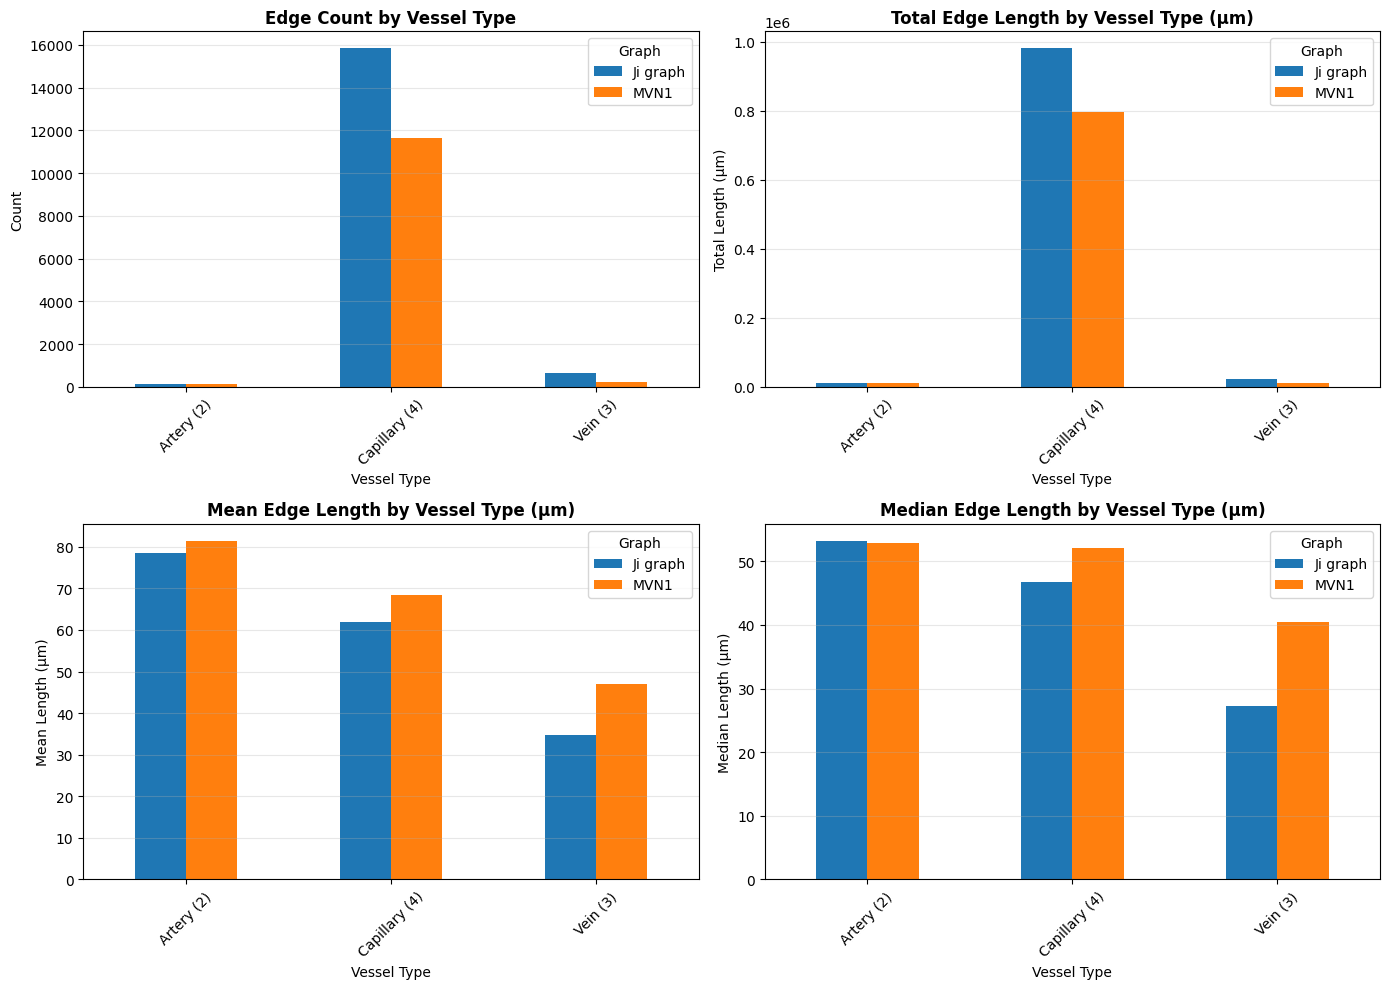


=== Interpretation ===
MVN1 total length (expected nkinds): 817435.73 μm
Ji graph total length (expected nkinds): 1015727.56 μm

Note: These are 2 different brain samples, so absolute lengths are expected to differ.
Focus on the relative composition (% of each vessel type) for validation.

=== Relative vessel type composition ===

               MVN1 (%)  Ji graph (%)
vessel_type                          
Artery (2)          1.3           1.2
Capillary (4)      97.4          96.6
Vein (3)            1.3           2.2


In [20]:
# Compare MVN1 vs Ji graph: edge lengths by nkind with correct unit conversion
# NOTE: MVN1 is in SI units (meters), Ji graph is in voxels (1 voxel = 1 μm isotropic)
# Conversion: MVN1 (m) × 1e6 → μm, so both graphs end up in μm

import matplotlib.pyplot as plt
import seaborn as sns

print("=== Unit analysis ===")
print("MVN1: stored in SI units (meters) → convert to μm by multiplying by 1e6")
print("Ji graph: stored in voxels (1 voxel = 1 μm isotropic) → already in μm")
print("→ Both graphs will be compared in μm\n")

# Extract edge lengths and convert MVN1 to μm
df_mvn1 = pd.DataFrame({
    "nkind": g1.es["nkind"],
    "length": np.array(g1.es["length"]) * 1e6,  # Convert from m to μm
})
df_mvn1 = df_mvn1.dropna(subset=["nkind", "length"]).copy()
df_mvn1["nkind"] = df_mvn1["nkind"].astype(int)

print("=== MVN1 nkind distribution (all values, in μm) ===\n")
summary_mvn1_all = (
    df_mvn1.groupby("nkind")["length"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .round(2)
    .sort_values("nkind")
)
print(summary_mvn1_all)
print()

# Ji graph is already in μm (voxels = 1 μm)
df_ji = pd.DataFrame({
    "nkind": g2.es["nkind"],
    "length": g2.es["length"],
})
df_ji = df_ji.dropna(subset=["nkind", "length"]).copy()
df_ji["nkind"] = df_ji["nkind"].astype(int)

print("=== Ji graph nkind distribution (in μm) ===\n")
summary_ji_all = (
    df_ji.groupby("nkind")["length"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .round(2)
    .sort_values("nkind")
)
print(summary_ji_all)
print()

# Filter to expected nkinds and add labels for plotting
expected_nkinds = [2, 3, 4]
nkind_names = {2: "Artery (2)", 3: "Vein (3)", 4: "Capillary (4)"}

df_mvn1_filtered = df_mvn1[df_mvn1["nkind"].isin(expected_nkinds)].copy()
df_mvn1_filtered["graph"] = "MVN1"
df_mvn1_filtered["vessel_type"] = df_mvn1_filtered["nkind"].map(nkind_names)

df_ji_filtered = df_ji[df_ji["nkind"].isin(expected_nkinds)].copy()
df_ji_filtered["graph"] = "Ji graph"
df_ji_filtered["vessel_type"] = df_ji_filtered["nkind"].map(nkind_names)

# Combine for comparison
df_combined = pd.concat([df_mvn1_filtered, df_ji_filtered], ignore_index=True)

# Summary table
print("=== Total lengths by vessel type (μm) ===\n")
summary_comparison = (
    df_combined.groupby(["vessel_type", "graph"])["length"]
    .agg(["count", "sum", "mean", "median"])
    .reset_index()
    .round(2)
)
print(summary_comparison.to_string(index=False))
print()

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Edge count by vessel type
pivot_count = summary_comparison.pivot(index="vessel_type", columns="graph", values="count")
pivot_count.plot(kind="bar", ax=axes[0, 0], color=["#1f77b4", "#ff7f0e"])
axes[0, 0].set_title("Edge Count by Vessel Type", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Vessel Type")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(title="Graph")
axes[0, 0].grid(axis="y", alpha=0.3)
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: Total edge length by vessel type
pivot_sum = summary_comparison.pivot(index="vessel_type", columns="graph", values="sum")
pivot_sum.plot(kind="bar", ax=axes[0, 1], color=["#1f77b4", "#ff7f0e"])
axes[0, 1].set_title("Total Edge Length by Vessel Type (μm)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Vessel Type")
axes[0, 1].set_ylabel("Total Length (μm)")
axes[0, 1].legend(title="Graph")
axes[0, 1].grid(axis="y", alpha=0.3)
axes[0, 1].tick_params(axis="x", rotation=45)

# Plot 3: Mean edge length by vessel type
pivot_mean = summary_comparison.pivot(index="vessel_type", columns="graph", values="mean")
pivot_mean.plot(kind="bar", ax=axes[1, 0], color=["#1f77b4", "#ff7f0e"])
axes[1, 0].set_title("Mean Edge Length by Vessel Type (μm)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Vessel Type")
axes[1, 0].set_ylabel("Mean Length (μm)")
axes[1, 0].legend(title="Graph")
axes[1, 0].grid(axis="y", alpha=0.3)
axes[1, 0].tick_params(axis="x", rotation=45)

# Plot 4: Median edge length by vessel type
pivot_median = summary_comparison.pivot(index="vessel_type", columns="graph", values="median")
pivot_median.plot(kind="bar", ax=axes[1, 1], color=["#1f77b4", "#ff7f0e"])
axes[1, 1].set_title("Median Edge Length by Vessel Type (μm)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Vessel Type")
axes[1, 1].set_ylabel("Median Length (μm)")
axes[1, 1].legend(title="Graph")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Print interpretation
print("\n=== Interpretation ===")
mvn1_total = df_mvn1_filtered['length'].sum()
ji_total = df_ji_filtered['length'].sum()
print(f"MVN1 total length (expected nkinds): {mvn1_total:.2f} μm")
print(f"Ji graph total length (expected nkinds): {ji_total:.2f} μm")
print("\nNote: These are 2 different brain samples, so absolute lengths are expected to differ.")
print("Focus on the relative composition (% of each vessel type) for validation.")

# Relative composition
print("\n=== Relative vessel type composition ===\n")
mvn1_pct = (df_mvn1_filtered.groupby("vessel_type")["length"].sum() / mvn1_total * 100).round(1)
ji_pct = (df_ji_filtered.groupby("vessel_type")["length"].sum() / ji_total * 100).round(1)
comp_df = pd.DataFrame({"MVN1 (%)": mvn1_pct, "Ji graph (%)": ji_pct})
print(comp_df)